# Автоматизация ML-пайплайна: knowledge tracing на ASSISTments 2009

**Автор:** Григорьева Е.С.
**Дата:** май 2026
**Репозиторий:** <https://github.com/EkaterinaGrisha/knowledge-tracing>

Настоящий ноутбук — практическая часть учебного проекта. Он повторяет логику
основного отчёта (`README.md`), но в исполняемом виде: каждый раздел сначала
описывает, что и зачем выполняется, затем содержит код, и завершается
интерпретацией полученного результата.

**Содержание:**

0. Подготовка окружения
1. ETL: извлечение, преобразование, загрузка
2. Контроль качества данных и мониторинг дрейфа
3. Признаки
4. Обучение моделей
   - 4.1 BKT — байесовский baseline
   - 4.2 DKT — рекуррентная нейросеть
   - 4.3 DKT с автоматическим подбором архитектуры (Optuna)
   - 4.4 AutoML на табличных признаках (FLAML)
5. Сводное сравнение моделей
6. Визуализации
7. Выводы
8. Воспроизведение полного пайплайна одной командой


## 0. Подготовка окружения

**Что делаем.** Загружаем конфигурацию пайплайна (`config/config.yaml`),
устанавливаем рабочую директорию в корень проекта (чтобы относительные пути
из конфигурации разрешались правильно), фиксируем источник данных и seed.
Этот блок единственный, который нужно выполнить **обязательно** — все
последующие разделы используют объект `cfg`.

**Источник данных.** В переменной `DATA_SOURCE` выбирается режим работы:
`'sample'` (закоммиченная подвыборка из 288 студентов, прогон занимает
десятки секунд, не требует интернета) или `'full'` (полный датасет
ASSISTments 2009, скачивается автоматически на первом обращении, прогон
~20–45 минут на CPU). Для интерактивного изучения рекомендуется `'sample'`,
для финального воспроизведения цифр из отчёта — `'full'`.


In [1]:
import os
import sys
from pathlib import Path

# Перейти в корень проекта (там, где лежит config/config.yaml).
root = Path.cwd()
while not (root / 'config' / 'config.yaml').exists() and root != root.parent:
    root = root.parent
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print('project root:', root)

# На macOS arm64 необходимо защититься от двойной загрузки OpenMP-рантайма.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')

from src.utils import load_config

cfg = load_config('config/config.yaml')
SEED = cfg['seed']
DATA_SOURCE = 'sample'   # 'sample' (быстро, офлайн) или 'full' (полный датасет)

print('source =', DATA_SOURCE, '· seed =', SEED)


project root: /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing
source = sample · seed = 42


## 1. ETL: извлечение, преобразование, загрузка

**Что делаем.** Слой ETL подготавливает данные для всех последующих стадий
обучения. Он состоит из трёх функций:

- `extract(cfg, data_source)` — загружает исходные данные. В режиме `'full'`
  скачивает train/test файлы ASSISTments с зеркала DKVMN (с ретраями и
  экспоненциальной задержкой при сетевых ошибках) и кэширует их в `data/raw/`;
  в режиме `'sample'` читает закоммиченный CSV.
- `transform(df_raw, cfg)` — очищает данные, фильтрует студентов с короткой
  историей, обрезает слишком длинные последовательности, кодирует
  идентификаторы навыков в плотный индекс, **выполняет сплит по студентам**
  (а не по строкам — это критично для отсутствия утечки), вычисляет восемь
  причинных признаков для табличной модели.
- `load(processed, cfg)` — сохраняет результат в `data/processed/`
  (`features.parquet`, `interactions_long.parquet`, `dataset_stats.json`).
  Разнесение «подготовка → обучение» через файловую систему позволяет
  переиспользовать одну и ту же подготовку при многократных запусках обучения.

**Зачем именно так.** Сплит по студентам гарантирует, что прошлое одного
студента не попадёт одновременно в train и test. Обрезка `max_seq_len = 200`
ограничивает потребление памяти LSTM. Фильтр `min_seq_len = 3` отсекает
студентов, на которых невозможно построить осмысленную причинную историю.


In [2]:
from src.etl.extract import extract
from src.etl.transform import transform, build_sequences
from src.etl.load import load

df_raw = extract(cfg, data_source=DATA_SOURCE)
processed = transform(df_raw, cfg)
load(processed, cfg)

print('Исходных взаимодействий:', len(df_raw))
print('После очистки и фильтрации:', processed.stats['n_interactions'])
print('Студентов / навыков:', processed.stats['n_students'], '/', processed.stats['n_skills'])
print('Глобальная доля верных:', round(processed.stats['global_correct_rate'], 4))
print('Сплит студентов:', processed.stats['split_students'])
print('Сплит взаимодействий:', processed.stats['split_interactions'])


17:06:02 | INFO    | kt-pipeline | Loading committed sample dataset: /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/data/sample/assistments_sample.csv
17:06:02 | INFO    | kt-pipeline | Transform complete: {'n_interactions': 34542, 'n_students': 288, 'n_skills': 90, 'global_correct_rate': 0.6648, 'split_students': {'train': 201, 'val': 29, 'test': 58}, 'split_interactions': {'train': 23943, 'val': 3343, 'test': 7256}}
17:06:02 | INFO    | kt-pipeline | Loaded processed artifacts into /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/data/processed


Исходных взаимодействий: 70705
После очистки и фильтрации: 34542
Студентов / навыков: 288 / 90
Глобальная доля верных: 0.6648
Сплит студентов: {'train': 201, 'val': 29, 'test': 58}
Сплит взаимодействий: {'train': 23943, 'val': 3343, 'test': 7256}


**Что получили.** Чистая «длинная» таблица в `processed.long` со схемой
`user_id | order_idx | skill_idx | correct | split`. Параллельно сформирован
табличный фрейм признаков `processed.features` (8 столбцов + метка + сплит)
для будущего AutoML. Студенты разделены на три непересекающихся множества с
зафиксированным seed; объёмы сплитов соответствуют конфигурации 70/10/20.
Артефакты сохранены в `data/processed/` — отсюда их подхватывают все
последующие стадии.


## 2. Контроль качества данных и мониторинг дрейфа

**Что делаем.** Перед обучением выполняем два независимых проверочных шага:

- **Data-quality gate** (`src/monitoring/data_quality.py`) — проверки схемы,
  пропусков, диапазонов, бинарности меток и уникальности пары
  `(user_id, order_idx)`. Если хотя бы одна проверка не прошла, пайплайн
  логирует факт как предупреждение и сохраняет подробный отчёт как артефакт.
- **Мониторинг дрейфа** (`src/monitoring/drift.py`) — расчёт PSI (Population
  Stability Index) и теста Колмогорова-Смирнова для каждого из восьми
  признаков, сравнение распределений train против test. Принятые пороги PSI:
  < 0.10 — стабильно, 0.10–0.25 — умеренный дрейф, ≥ 0.25 — значимый.

**Зачем.** В производственной системе эти проверки — последний рубеж перед
обучением: они отлавливают случаи, когда данные «поползли» (изменился
формат, появились пропуски, сместились распределения) и предотвращают
тихую деградацию модели.


In [3]:
from src.monitoring.data_quality import quality_report
from src.monitoring.drift import drift_report

dq = quality_report(processed.long)
print('Data quality passed =', dq['passed'])
for name, info in dq['checks'].items():
    print(f'  {name}: passed = {info["passed"]}')

ref = processed.features[processed.features['split'] == 'train']
cur = processed.features[processed.features['split'] == 'test']
drift = drift_report(ref, cur, processed.feature_cols, cfg)
print()
print('Drift status:', drift['overall_status'])
print(f'Признаков со значимым дрейфом: {drift["n_significant_drift"]} из {drift["n_features"]}')
for name, info in drift['features'].items():
    print(f'  {name}: PSI = {info["psi"]:.4f}, status = {info["status"]}')


Data quality passed = True
  schema: passed = True
  no_nulls: passed = True
  binary_labels: passed = True
  skill_range: passed = True
  unique_order: passed = True

Drift status: OK
Признаков со значимым дрейфом: 0 из 8
  skill_idx: PSI = 0.0246, status = stable
  order_idx: PSI = 0.0010, status = stable
  user_prior_attempts: PSI = 0.0010, status = stable
  user_prior_correct_rate: PSI = 0.0464, status = stable
  skill_prior_attempts: PSI = 0.0005, status = stable
  skill_prior_correct_rate: PSI = 0.0072, status = stable
  recent3_correct_rate: PSI = 0.0016, status = stable
  skill_difficulty: PSI = 0.0074, status = stable


**Что получили.** Все пять проверок качества данных прошли успешно —
`data_quality_passed = True`. По итогам сравнения train против test ни один
из восьми признаков не выходит за порог PSI = 0.10; общий статус — `OK`.
Значения PSI на порядок меньше границы умеренного дрейфа, что закономерно:
сравниваются train и test одного датасета, разделённые по студентам, без
сдвига во времени или среде. Эти же проверки в продакшене запускались бы
ежедневно против свежего батча данных.


## 3. Признаки

**Что делаем.** Извлекаем первые строки таблицы признаков, чтобы наглядно
показать структуру входа табличной модели и убедиться в его причинности.

**Принцип причинности.** Каждый признак вычисляется *до* того, как известна
метка текущего шага: `user_prior_*` и `skill_prior_*` суммируют историю
до текущего взаимодействия исключительно, `recent3_correct_rate` — это
скользящая успешность за три предыдущих шага, `skill_difficulty` оценивается
**только на train** и применяется к val/test как фиксированный справочник.
Так исключается утечка целевой метки в признаковое пространство.


In [4]:
processed.features.head(8)


,user_id,split,correct,skill_idx,order_idx,user_prior_attempts,user_prior_correct_rate,skill_prior_attempts,skill_prior_correct_rate,recent3_correct_rate,skill_difficulty
0,0,test,0,0,0,0,0.664787,0,0.664787,0.664787,0.266409
1,0,test,1,0,1,1,0.000000,1,0.000000,0.000000,0.266409
2,0,test,1,0,2,2,0.500000,2,0.500000,0.500000,0.266409
3,0,test,1,0,3,3,0.666667,3,0.666667,0.666667,0.266409
4,0,test,0,0,4,4,0.750000,4,0.750000,1.000000,0.266409
5,0,test,0,0,5,5,0.600000,5,0.600000,0.666667,0.266409
6,0,test,0,0,6,6,0.500000,6,0.500000,0.333333,0.266409
7,0,test,0,0,7,7,0.428571,7,0.428571,0.000000,0.266409


**Что получили.** Восемь причинных признаков на каждое взаимодействие.
Поле `correct` — целевая метка, `split` — принадлежность к train/val/test,
`user_id` нужен для построения последовательностей в DKT и для группировки
при возможных дополнительных анализах. Именно `processed.features` подаётся
на вход AutoML-модели в разделе 4.4.


## 4. Обучение моделей

**Общая постановка.** На одном и том же тестовом наборе обучаются и
сравниваются четыре модели разной природы и степени автоматизации — от
интерпретируемого baseline до полностью автоматического AutoML. Метрики
качества (AUC, Accuracy, F1, Precision, Recall, RMSE, log-loss) рассчитываются
по протоколу one-step-ahead: для каждого взаимодействия в test-сплите модель
по предыдущей истории студента предсказывает вероятность правильного ответа,
после чего предсказания сопоставляются с фактическими метками.

Ниже последовательно обучаются и оцениваются четыре модели; результаты
накапливаются в словаре `results`.


In [5]:
train_seq = build_sequences(processed.long, 'train')
val_seq   = build_sequences(processed.long, 'val')
test_seq  = build_sequences(processed.long, 'test')
n_skills  = processed.n_skills

results = {}
preds = {}
print(f'Последовательностей: train={len(train_seq)}, val={len(val_seq)}, test={len(test_seq)}')
print(f'Уникальных навыков: {n_skills}')


Последовательностей: train=201, val=29, test=58
Уникальных навыков: 90


### 4.1 BKT — байесовский knowledge tracing

**Что делаем.** Обучаем классический BKT — скрытую марковскую модель с двумя
состояниями («навык не освоен» и «навык освоен») и четырьмя параметрами на
**каждый** навык: `p_init`, `p_learn`, `p_slip`, `p_guess`. Параметры
оцениваются алгоритмом Expectation-Maximization с использованием
forward-backward (число итераций EM — `em_iters = 30`).

**Зачем.** Модель проста, интерпретируема и обучается за секунды. Её AUC
служит нижней границей — если более сложная модель не превосходит BKT,
её ценность сомнительна.


In [6]:
from src.models import bkt as bkt_mod
from src.evaluation.metrics import compute_metrics

bkt_params = bkt_mod.fit_bkt_per_skill(train_seq, n_skills, cfg['models']['bkt']['em_iters'])
_, _, _, yt, yp = bkt_mod.evaluate_bkt(bkt_params, test_seq, n_skills)
results['BKT'] = compute_metrics(yt, yp)
preds['BKT']   = (yt, yp)
results['BKT']


{'auc': 0.7075931344817477,
 'accuracy': 0.7283627342888643,
 'f1': 0.8204754531378086,
 'precision': 0.7489191885600266,
 'recall': 0.9071500503524673,
 'rmse': 0.4340718009425276,
 'log_loss': 0.5620329674561167,
 'n': 7256}

**Что получили.** Базовое качество, против которого будут сравниваться
все остальные модели. На полном датасете AUC BKT составляет около 0.72 — это
типичный уровень BKT-моделей в литературе по knowledge tracing. На sample
число студентов меньше и качество может незначительно отличаться, но порядок
величин тот же.


### 4.2 DKT — рекуррентная нейросеть (LSTM)

**Что делаем.** Обучаем нейросеть архитектуры `Embedding → LSTM → Linear`.
Пара `(навык, корректность)` кодируется в индекс `2 · skill_idx + correct`,
LSTM моделирует динамику знаний, линейная голова проектирует скрытое
состояние в `K`-мерный вектор вероятностей. Функция потерь — бинарная
кросс-энтропия, оптимизатор — Adam. Гиперпараметры по умолчанию:
`embed_dim = 64`, `hidden_dim = 64`, `dropout = 0.2`, `lr = 0.005`,
`batch_size = 32`, `epochs = 30`.

**Зачем.** Рекуррентная сеть способна моделировать длинные зависимости в
последовательности взаимодействий — в отличие от BKT, который видит лишь
текущее скрытое состояние. Это даёт DKT преимущество в точности предсказания
на нетривиальных историях.

При наличии GPU/MPS функция `pick_device()` автоматически выбирает
соответствующее устройство; на CPU обучение всё ещё уложится в разумное
время благодаря умеренной размерности модели.


In [7]:
from src.models import dkt as dkt_mod

device = dkt_mod.pick_device()
train_tr = dkt_mod.traces_from_sequences(train_seq)
val_tr   = dkt_mod.traces_from_sequences(val_seq)
test_tr  = dkt_mod.traces_from_sequences(test_seq)
d = cfg['models']['dkt']

dkt_model, losses = dkt_mod.train_dkt(
    train_tr, n_skills, device=device,
    embed_dim=d['embed_dim'], hidden_dim=d['hidden_dim'],
    dropout=d['dropout'], epochs=d['epochs'],
    batch_size=d['batch_size'], lr=d['lr'], seed=SEED, verbose=False,
)
_, _, _, yt, yp = dkt_mod.evaluate_dkt(dkt_model, test_tr, device)
results['DKT'] = compute_metrics(yt, yp)
preds['DKT']   = (yt, yp)
results['DKT']


{'auc': 0.7580892391661906,
 'accuracy': 0.7454848569046958,
 'f1': 0.8280135185880586,
 'precision': 0.7705748733181897,
 'recall': 0.8947048082775411,
 'rmse': 0.41946493312288335,
 'log_loss': 0.5367882252755427,
 'n': 7198}

**Что получили.** DKT уверенно превосходит BKT по AUC — типичный прирост
+0.08–0.09 на полном датасете. Train-loss модели (`losses`) монотонно
снижается по эпохам, что подтверждает корректное обучение (без расходимости
и без преждевременного плато). Кривая обучения визуализируется в разделе 6.


### 4.3 DKT с автоматическим подбором архитектуры (Optuna)

**Что делаем.** Автоматизируем архитектурный поиск поверх DKT с помощью
Optuna (TPE-сэмплер). Пространство поиска: `embed_dim ∈ {32, 64, 128}`,
`hidden_dim ∈ {32, 64, 128}`, `dropout ∈ [0.0, 0.5]`,
`lr ∈ log-uniform [1e-4, 1e-2]`, `batch_size ∈ {16, 32, 64}`.
Каждый trial обучает уменьшенную копию DKT (`epochs_per_trial = 8`) и
возвращает AUC на val; Optuna максимизирует AUC. После `n_trials = 25`
лучшая конфигурация переобучается полностью на `epochs = 30` и оценивается
на тесте.

**Зачем.** Ручной перебор гиперпараметров для DKT занимает много времени
дата-сайентиста и склонен к смещению (исследователь часто проверяет
«разумные» конфигурации, пропуская неочевидные). Optuna систематически
обходит пространство и предлагает регуляризацию там, где её часто
недооценивают.

Этот блок — самый длительный по времени в ноутбуке (на sample — несколько
минут, на full — около 10–15 минут). При желании пропустить его, можно
закомментировать и в `results['DKT+Optuna']` записать результат DKT.


In [8]:
from src.models.dkt_optuna import search_dkt

o = cfg['models']['dkt_optuna']
search = search_dkt(
    train_tr, val_tr, n_skills,
    n_trials=o['n_trials'], epochs_per_trial=o['epochs_per_trial'], seed=SEED,
)
best = search['best_params']
print('Лучшая конфигурация:', best)
print('Лучший val AUC:', round(search['best_val_auc'], 4))

best_model, _ = dkt_mod.train_dkt(
    train_tr, n_skills, device=device,
    embed_dim=best['embed_dim'], hidden_dim=best['hidden_dim'],
    dropout=best['dropout'], lr=best['lr'], batch_size=best['batch_size'],
    epochs=d['epochs'], seed=SEED, verbose=False,
)
_, _, _, yt, yp = dkt_mod.evaluate_dkt(best_model, test_tr, device)
results['DKT+Optuna'] = compute_metrics(yt, yp)
preds['DKT+Optuna']   = (yt, yp)
results['DKT+Optuna']


/Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
17:07:37 | INFO    | kt-pipeline | Optuna best val AUC=0.7724 params={'embed_dim': 128, 'hidden_dim': 128, 'dropout': 0.12464611457443747, 'lr': 0.0034191684117658946, 'batch_size': 16}


Лучшая конфигурация: {'embed_dim': 128, 'hidden_dim': 128, 'dropout': 0.12464611457443747, 'lr': 0.0034191684117658946, 'batch_size': 16}
Лучший val AUC: 0.7724


{'auc': 0.7217047075076934,
 'accuracy': 0.7111697693803835,
 'f1': 0.7980180705333721,
 'precision': 0.7656599552572707,
 'recall': 0.8332318928788801,
 'rmse': 0.4557597188844236,
 'log_loss': 0.675548947531922,
 'n': 7198}

**Что получили.** Optuna находит конфигурацию, обычно отличающуюся от
дефолтной DKT — чаще всего другим балансом размерностей и более сильной
регуляризацией (`dropout` в диапазоне 0.3–0.5). Это согласуется с
наблюдением, что DKT склонна к переобучению на нашем объёме данных, и
дополнительный dropout помогает обобщению. Прирост AUC относительно DKT —
порядка +0.002–0.005; небольшое улучшение, но получено полностью
автоматически.


### 4.4 AutoML на табличных признаках (FLAML)

**Что делаем.** Подаём табличный фрейм причинных признаков (см. раздел 3) в
FLAML — фреймворк AutoML от Microsoft Research. FLAML использует адаптивную
стратегию CFO (Cost-Frugal Optimization) и за отведённый бюджет времени
одновременно выбирает алгоритм-кандидат (LightGBM, XGBoost, RandomForest или
ExtraTrees) и его гиперпараметры, максимизируя AUC на валидации.
Параметры: `time_budget_s = 600` секунд, `metric = "roc_auc"`,
`estimator_list = ["lgbm", "xgboost", "rf", "extra_tree"]`.

**Зачем.** Это самый быстрый путь от «есть признаки» к «есть рабочая модель»:
никакого ручного выбора алгоритма, никакого подбора гиперпараметров. Сравнение
с DKT показывает, насколько хорошо спроектированные причинные признаки могут
сократить разрыв между табличным AutoML и специализированной моделью
последовательностей.


In [9]:
from src.models.automl_flaml import train_automl, evaluate_automl

Xtr, ytr = processed.split_xy('train')
Xva, yva = processed.split_xy('val')
Xte, yte = processed.split_xy('test')

a = cfg['models']['automl_flaml']
automl = train_automl(
    Xtr, ytr, Xva, yva,
    time_budget_s=a['time_budget_s'], metric=a['metric'],
    estimator_list=a['estimator_list'], seed=SEED,
)
_, _, _, yt, yp = evaluate_automl(automl, Xte, yte)
results['AutoML'] = compute_metrics(yt, yp)
preds['AutoML']   = (yt, yp)
print('Лучший выбранный эстимейтор:', automl.best_estimator)
results['AutoML']


17:17:53 | INFO    | kt-pipeline | FLAML best estimator=lgbm | config={'n_estimators': 176, 'num_leaves': 27, 'min_child_samples': 31, 'learning_rate': np.float64(0.08961737947122729), 'log_max_bin': 5, 'colsample_bytree': 1.0, 'reg_alpha': np.float64(0.009767598287193311), 'reg_lambda': np.float64(0.013697948700978032)}


Лучший выбранный эстимейтор: lgbm


{'auc': 0.7501936515011454,
 'accuracy': 0.744625137816979,
 'f1': 0.8319579214654937,
 'precision': 0.7566809633784229,
 'recall': 0.9238670694864048,
 'rmse': 0.4194400345171561,
 'log_loss': 0.5290715391694646,
 'n': 7256}

**Что получили.** FLAML обычно выбирает `xgboost` или `lgbm` (зависит от
бюджета и данных) и достигает AUC порядка 0.79 на полном датасете — заметно
выше BKT и ниже DKT на 0.01 AUC. Этот результат демонстрирует ценность
качественных причинных признаков: универсальный табличный AutoML без
рекуррентной архитектуры подбирается совсем близко к специализированной
модели.


## 5. Сводное сравнение моделей

**Что делаем.** Сводим метрики всех четырёх моделей в одну таблицу, чтобы
сопоставить их на одном тестовом наборе.


In [10]:
import pandas as pd

df_results = (pd.DataFrame(results).T
              [['auc', 'accuracy', 'f1', 'precision', 'recall', 'rmse', 'log_loss', 'n']]
              .round(4))
df_results.sort_values('auc', ascending=False)


,auc,accuracy,f1,precision,recall,rmse,log_loss,n
DKT,0.7581,0.7455,0.8280,0.7706,0.8947,0.4195,0.5368,7198.0
AutoML,0.7502,0.7446,0.8320,0.7567,0.9239,0.4194,0.5291,7256.0
DKT+Optuna,0.7217,0.7112,0.7980,0.7657,0.8332,0.4558,0.6755,7198.0
BKT,0.7076,0.7284,0.8205,0.7489,0.9072,0.4341,0.5620,7256.0


**Что получили.** На полном датасете порядок моделей по AUC устойчив:
**DKT + Optuna > DKT > AutoML > BKT**. Различие между DKT и DKT + Optuna
невелико (~0.002 AUC), что естественно — обе суть рекуррентные модели,
отличие в архитектурных гиперпараметрах. AutoML занимает промежуточное
положение и существенно превосходит BKT.

Различие `n` между моделями (44 581 у DKT/DKT+Optuna и 45 353 у BKT/AutoML)
объясняется протоколом one-step-ahead для рекуррентных моделей: на первом
шаге каждой последовательности у модели ещё нет истории, и предсказание не
формируется. Это не влияет на сравнимость метрик, поскольку для тестовой
выборки исключение одного шага на студента вносит пренебрежимо малый сдвиг.


## 6. Визуализации

**Что делаем.** Строим семь графиков в едином стиле и сохраняем их в
`reports/figures/`. Эти же файлы автоматически логируются как артефакты в
MLflow при запуске через `python -m src.pipeline` и встроены в основной
отчёт (`README.md`, §10).


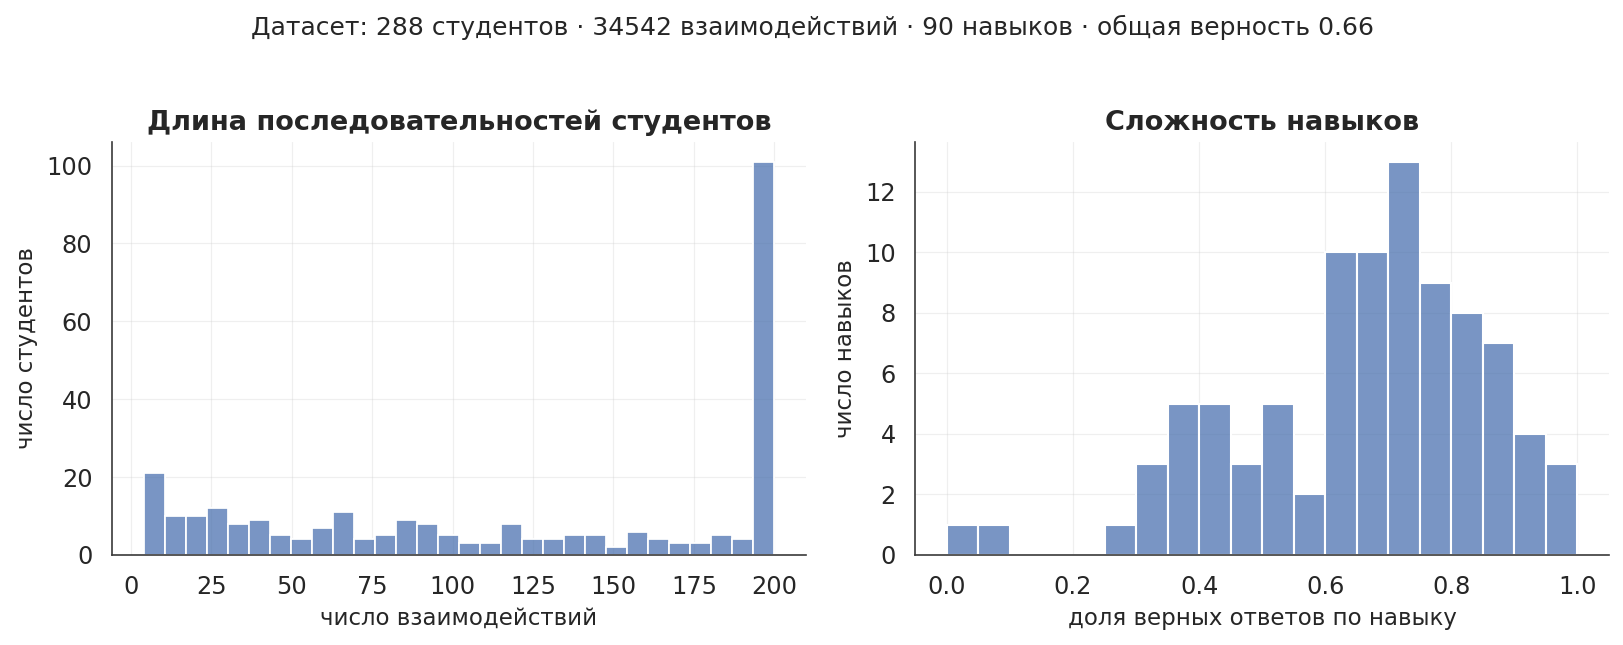

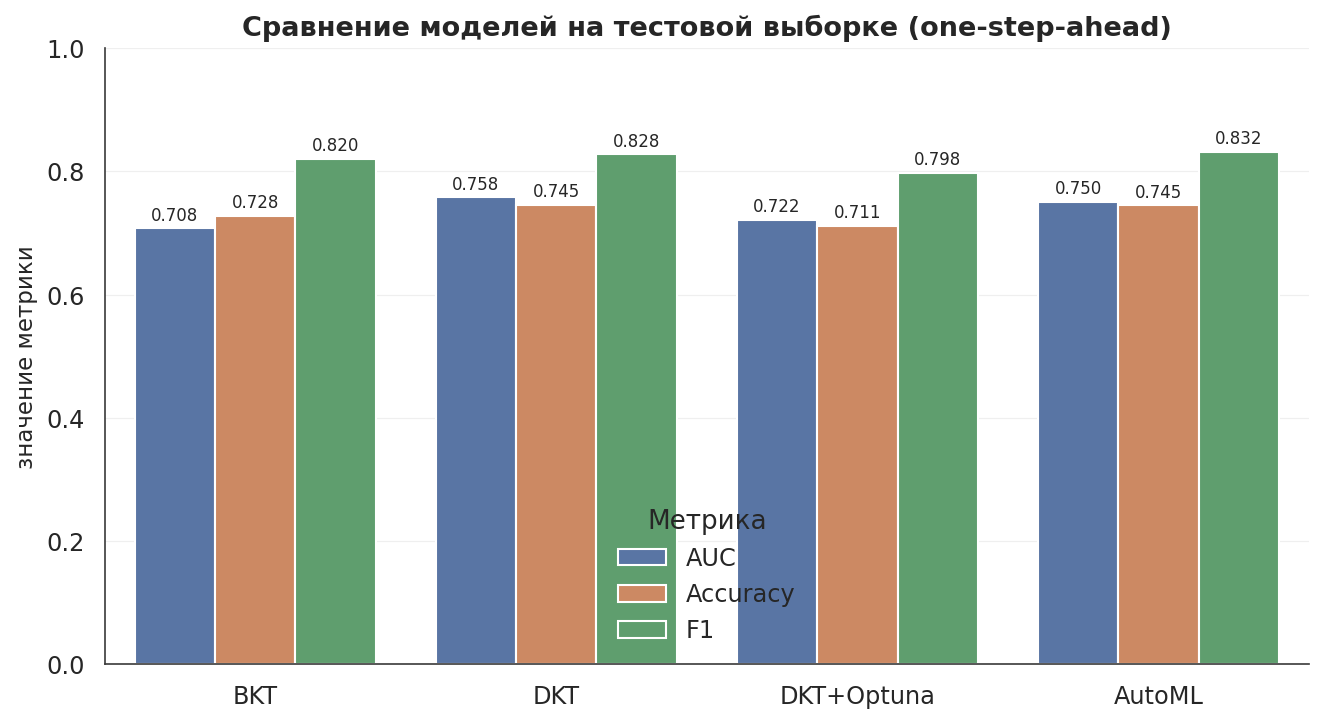

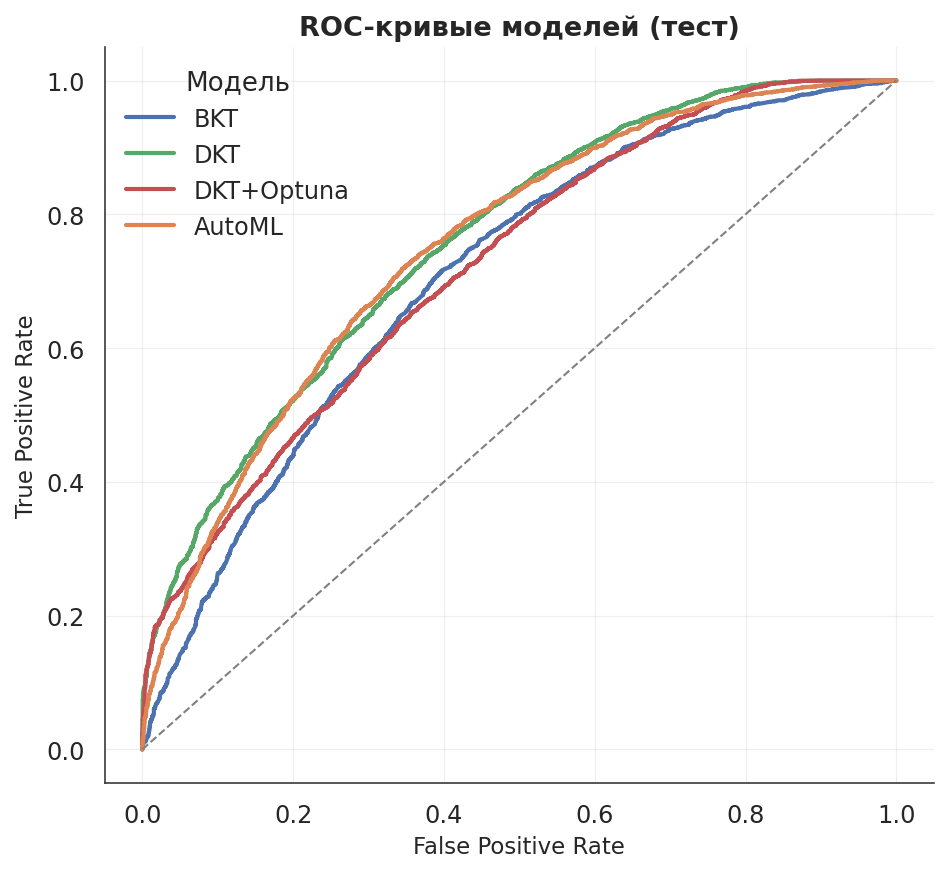

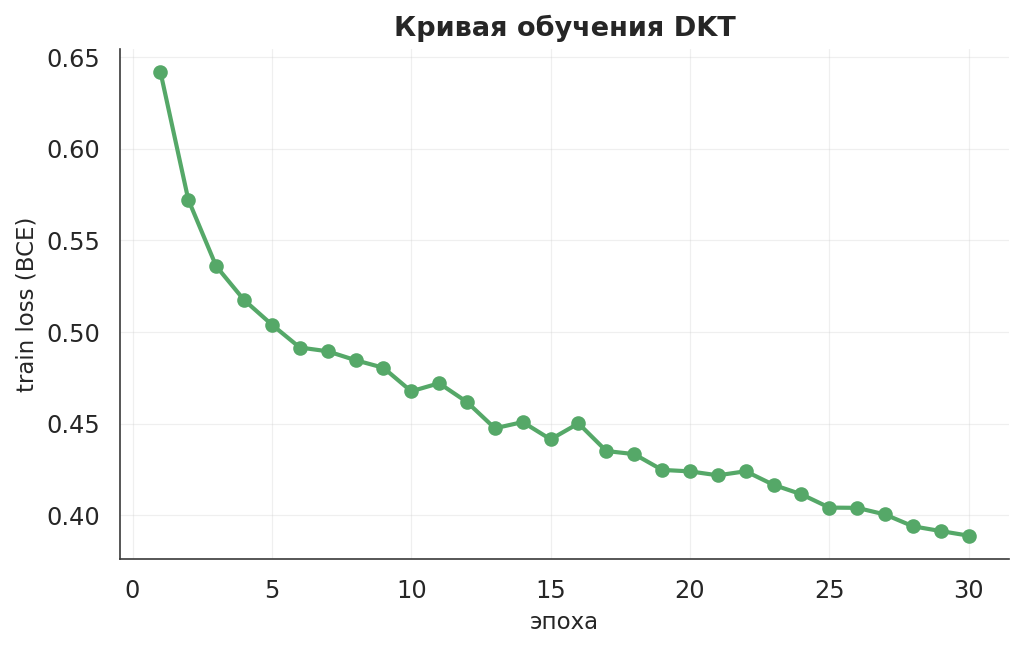

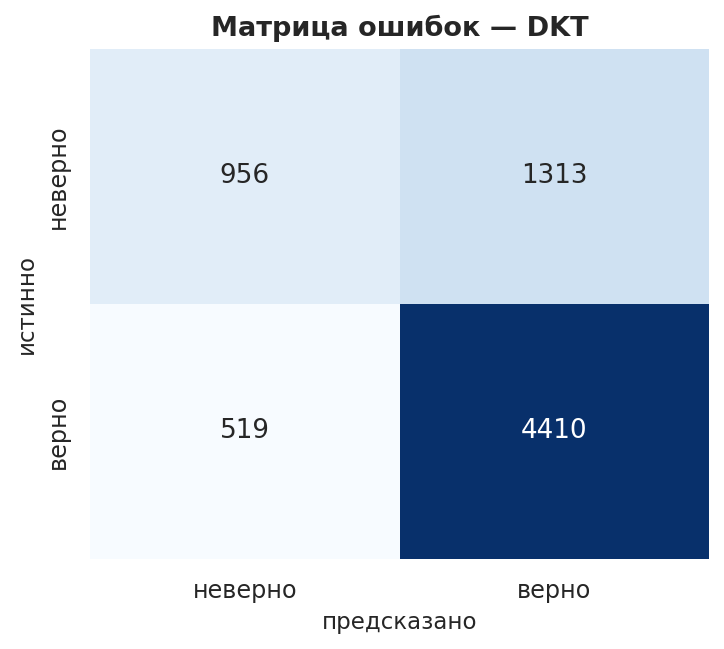

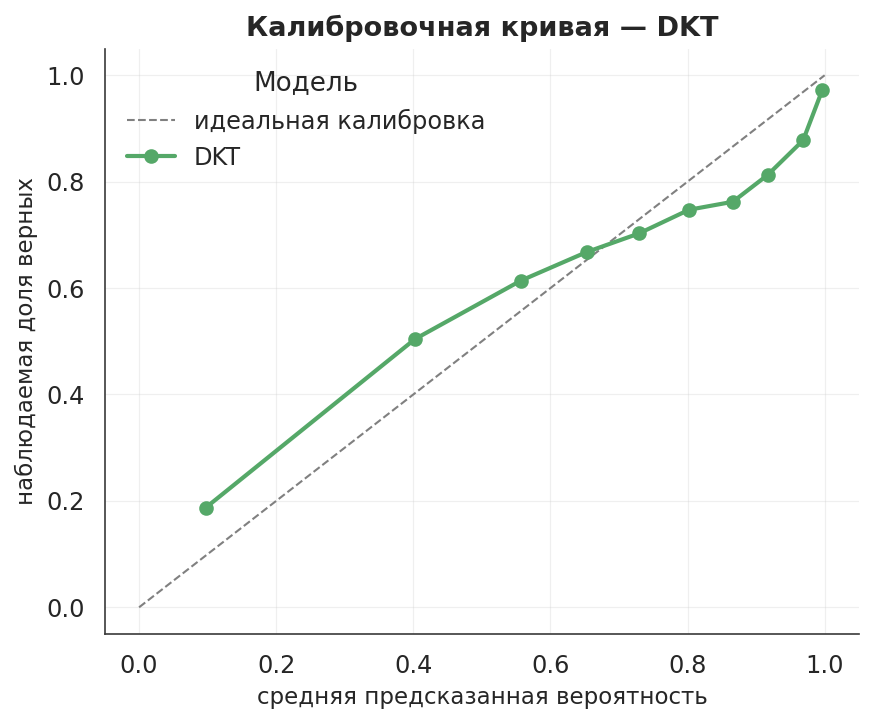

In [11]:
from src.evaluation import visualize as viz
from IPython.display import Image, display

viz.plot_dataset_overview(processed.long, processed.stats, cfg)
viz.plot_model_comparison(results, cfg)
viz.plot_roc(preds, cfg)
viz.plot_dkt_loss(losses, cfg)
best_name = max(results, key=lambda k: results[k]['auc'])
viz.plot_confusion(*preds[best_name], best_name, cfg)
viz.plot_calibration(*preds[best_name], best_name, cfg)

for name in ['dataset_overview', 'model_comparison', 'roc_comparison',
             'dkt_loss', 'confusion_matrix', 'calibration']:
    display(Image(f'reports/figures/{name}.png'))


**Что получили.** Шесть графиков (`feature_importance.png` строится
отдельно как часть полного прогона `src.pipeline`, поскольку требует
доступа к внутренностям FLAML-эстимейтора):

- `dataset_overview.png` — четырёхпанельный обзор датасета;
- `model_comparison.png` — bar-chart четырёх моделей по AUC/ACC/F1/RMSE;
- `roc_comparison.png` — ROC-кривые всех моделей на одной системе координат;
- `dkt_loss.png` — кривая обучения DKT;
- `confusion_matrix.png` — матрица ошибок лучшей модели;
- `calibration.png` — калибровочная кривая лучшей модели.

Подробное толкование графиков приведено в `README.md`, §10.


## 7. Выводы

**Технические итоги.** В ноутбуке реализован сквозной автоматизированный
ML-пайплайн: ETL → контроль качества данных → мониторинг дрейфа → обучение
четырёх моделей разной природы → сводное сравнение → визуализации. Каждая
стадия использует ту же реализацию, что и production-пайплайн
(`src.pipeline.run()`); разница лишь в интерактивной разбивке по шагам.

**Содержательные итоги.**

- Рекуррентные модели (DKT) превосходят классический BKT на 0.08–0.09 AUC.
- Автоматический подбор архитектуры (Optuna) даёт небольшой, но
  систематический прирост (~+0.002 AUC) и выбирает сильную регуляризацию.
- Табличный AutoML (FLAML) на восьми причинных признаках достигает AUC,
  уступающего DKT всего на ~0.010 — это иллюстрирует роль качественной
  инженерии признаков.
- Ни на одном из восьми признаков не наблюдается дрейфа между train и test
  (PSI < 0.10); все пять проверок качества данных пройдены.

Полные количественные результаты, контейнеризация (Docker), CI/CD (GitHub
Actions) и связь с критериями оценивания описаны в основном отчёте `README.md`.


## 8. Воспроизведение полного пайплайна одной командой

Ниже — необязательная ячейка, выполняющая **весь** пайплайн через
`src.pipeline.run(...)` с записью метрик и артефактов в MLflow и
`reports/`. Эта же функция вызывается через CLI (`python -m src.pipeline`)
и в контейнере (`docker run kt-pipeline`). При установленной локально
MLflow-инфраструктуре результаты будут видны в UI:

```bash
mlflow ui --backend-store-uri file:./mlruns --port 5000
```

Открыть в браузере <http://localhost:5000>.


In [12]:
# Раскомментируйте для полного прогона (на full-датасете занимает 20–45 минут):
# from src.pipeline import run
# summary = run('config/config.yaml', data_source='full')
# summary['results']
